# Figure 3S1: Congruence by RT

## What this notebook does

For the OL (online) task, shows per-participant **congruence** — the fraction of trials
where `sign(bound)` matches the choice direction — as a function of RT, separately for
each of the three task blocks.

Congruence near 0.5 (chance) at short RTs indicates guessing or inattentive responding;
congruence rising toward 1.0 at longer RTs reflects genuine evidence accumulation.

**Figure** — 1 row × 3 columns (OL blocks 1–3):
Each point is one participant at one integer RT value, jittered horizontally for
visibility. Red circle = median across participants at that RT. Dotted line = chance (0.5).

**Data**: OL task, all subjects, all SNR levels pooled within each block.
Bias correction is not applied so that raw bound signs are used for congruence.

## Imports

Standard scientific Python libraries plus `get_data_table` from the pigeon package.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from pigeon.data import get_data_table
from pigeon.pathDefaults import FIGURES_DIR

## Load data

Loads all OL trials with `correct_bias=None`. Bias correction is skipped because we
only compare signs (`sign(bound)` vs. choice direction), and bias correction preserves
sign anyway — it adjusts magnitude only. Skipping it avoids unnecessary computation.

Adds a `trial_congruent` column: 1 if `sign(bound)` matches the choice direction,
0 if not, NaN if the bound is missing or the trial fails quality checks (wall-hit or
`trial_number < 10`). Wall-hit trials are excluded because their RT is inflated by
the screen edge and their bound estimates are unreliable.

**RT vs DT**: congruence is binned by total RT (not DT) to capture how evidence
accumulates over the full trial, including the post-crossing NDT steps. DT alone
would conflate short trials with large NDT with trials that resolved quickly.

In [ ]:
# Load data without bias correction (sign direction is unchanged by bias correction)
df = get_data_table(task_type='OL', correct_bias=None)

# Convert choice 0/1 → −1/+1 so we can compare signs directly with bound
choice_pm = df['choice'] * 2 - 1

df = df.copy()
df['trial_congruent'] = (np.sign(df['bound']) == np.sign(choice_pm)).astype(float)
df.loc[~np.isfinite(df['bound']),   'trial_congruent'] = np.nan  # missing bound
df.loc[df['wall_hit'] == True,      'trial_congruent'] = np.nan  # inflated RT
df.loc[df['trial_number'] < 10,     'trial_congruent'] = np.nan  # practice trials

print(f'Loaded {len(df):,} trials from {df.subject_index.nunique()} subjects')
print(f'Trials with valid congruence: {df.trial_congruent.notna().sum():,}')
print(f'Overall mean congruence: {df.trial_congruent.mean():.3f}')

## Parameters and per-subject congruence

**`BLOCKS`**: OL blocks 1–3 (one panel each).

**`RT_BINS`**: Integer RT values shown on the x-axis (1–10 steps covers the
vast majority of trials; the RT distribution has a median around 5 steps).

**`MIN_TRIALS`**: Minimum number of trials a subject must have at a given RT to
contribute a point. Prevents noisy single-trial estimates from dominating.

**`cong[block]`**: `(n_subjects, n_rt_bins)` array of per-subject mean congruence.
Entry is NaN where the subject has fewer than `MIN_TRIALS` trials at that RT.

In [3]:
BLOCKS     = [1, 2, 3]
RT_BINS    = np.arange(1, 11)  # show RT 1–10 steps
MIN_TRIALS = 5                 # minimum trials per (subject, RT) to show a point

BLOCK_LABELS = {1: 'Block 1', 2: 'Block 2', 3: 'Block 3'}

subjects   = np.sort(df['subject_index'].dropna().unique())
n_subjects = len(subjects)
rng        = np.random.default_rng(42)  # fixed seed for reproducible jitter

# For each block, build a (n_subjects x n_rt_bins) matrix of mean congruence.
# NaN where a subject has fewer than MIN_TRIALS trials at that RT.
cong = {}
for block in BLOCKS:
    block_df = df[df['block_index'] == block]
    mat = np.full((n_subjects, len(RT_BINS)), np.nan)

    for si, subj in enumerate(subjects):
        sub = block_df[block_df['subject_index'] == subj]
        for ri, rt in enumerate(RT_BINS):
            vals = sub.loc[sub['RT'] == rt, 'trial_congruent'].dropna()
            if len(vals) >= MIN_TRIALS:
                mat[si, ri] = vals.mean()

    cong[block] = mat
    n_pts = np.isfinite(mat).sum()
    print(f'Block {block}: {n_pts} subject×RT points across {n_subjects} subjects')

Block 1: 405 subject×RT points across 60 subjects
Block 2: 406 subject×RT points across 60 subjects
Block 3: 330 subject×RT points across 60 subjects


## Figure

1 row × 3 columns, one panel per OL block. Each point is one participant's mean
congruence at a given integer RT, jittered ±0.25 steps horizontally. Red circle
= median across participants. Dotted line = chance (0.5).

Layout: 14 cm wide, 4.5 cm tall, 1.0 cm horizontal panel separation.
Saves to `Figure03_S01.pdf`.

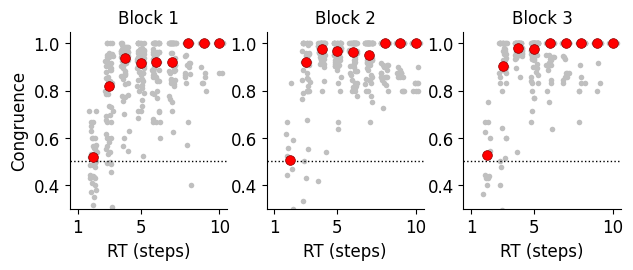

Saved /Users/jigold/Library/CloudStorage/Box-Box/GoldLab/Projects/2025_Pigeon/Figures/Figure03S1_congruenceByRT_formatted.pdf


In [ ]:
CM  = 1 / 2.54
WID = 14.0   # figure width (cm)
HT  = 4.5    # panel height (cm)
PSW = 1.0    # horizontal panel separation (cm)
FS  = 12     # font size (pt)

n_cols  = len(BLOCKS)
panel_w = (WID - PSW * (n_cols - 1)) / n_cols
wspace  = PSW / panel_w

plt.rcParams.update({'font.size': FS, 'axes.labelsize': FS, 'axes.titlesize': FS})

fig = plt.figure(figsize=(WID * CM, HT * CM))
gs  = gridspec.GridSpec(1, n_cols, figure=fig,
                        left=0, right=1, bottom=0, top=1,
                        wspace=wspace)
axs = [fig.add_subplot(gs[0, c]) for c in range(n_cols)]

for col_idx, block in enumerate(BLOCKS):
    ax  = axs[col_idx]
    mat = cong[block]

    for ri, rt in enumerate(RT_BINS):
        col   = mat[:, ri]
        valid = col[np.isfinite(col)]
        if len(valid) == 0:
            continue

        # Jitter points horizontally so overlapping subjects are visible
        jx = rt + rng.uniform(-0.25, 0.25, size=len(valid))
        ax.plot(jx, valid, 'o', color='0.75', markersize=4,
                markeredgecolor='none', zorder=2)

        # Median across subjects at this RT
        ax.plot(rt, np.median(valid), 'ro', markersize=7,
                markeredgecolor='darkred', markeredgewidth=0.5, zorder=5)

    # Chance reference line
    ax.axhline(0.5, color='k', linestyle=':', linewidth=1)

    ax.set_xlim(RT_BINS[0] - 0.5, RT_BINS[-1] + 0.5)
    ax.set_xticks([1, 5, 10])
    ax.set_ylim(0.3, 1.05)
    ax.set_xlabel('RT (steps)')
    ax.set_title(BLOCK_LABELS[block])
    if col_idx == 0:
        ax.set_ylabel('Congruence')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

out = FIGURES_DIR / 'Figure03_S01.pdf'
fig.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved {out}')